In [1]:
# =============================================
# Telecom Customer Churn Project
# Notebook 1 : EDA, SQL and Business Analysis
# =============================================

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

sns.set_theme(style = "whitegrid")

### Loading the dataset

In [3]:
file_path = "/Users/alankar/Downloads/Customer Churn Project/project/data/raw/Telco_customer_churn.xlsx"

df = pd.read_excel(file_path)
df

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,No,No,Yes,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,No,No,Yes,49,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,2569-WGERO,1,United States,California,Landers,92285,"34.341737, -116.539416",34.341737,-116.539416,Female,No,No,No,72,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Bank transfer (automatic),21.15,1419.4,No,0,45,5306,NaN
7039,6840-RESVB,1,United States,California,Adelanto,92301,"34.667815, -117.536183",34.667815,-117.536183,Male,No,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No,0,59,2140,NaN
7040,2234-XADUH,1,United States,California,Amboy,92304,"34.559882, -115.637164",34.559882,-115.637164,Female,No,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No,0,71,5560,NaN
7041,4801-JZAZL,1,United States,California,Angelus Oaks,92305,"34.1678, -116.86433",34.167800,-116.864330,Female,No,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No,0,59,2793,NaN


### Inspecting the dataset

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [5]:
df.describe()

,Count,Zip Code,Latitude,Longitude,Tenure Months,Monthly Charges,Churn Value,Churn Score,CLTV
count,7043.0,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,1.0,93521.964646,36.282441,-119.798880,32.371149,64.761692,0.265370,58.699418,4400.295755
std,0.0,1865.794555,2.455723,2.157889,24.559481,30.090047,0.441561,21.525131,1183.057152
min,1.0,90001.000000,32.555828,-124.301372,0.000000,18.250000,0.000000,5.000000,2003.000000
25%,1.0,92102.000000,34.030915,-121.815412,9.000000,35.500000,0.000000,40.000000,3469.000000
50%,1.0,93552.000000,36.391777,-119.730885,29.000000,70.350000,0.000000,61.000000,4527.000000
75%,1.0,95351.000000,38.224869,-118.043237,55.000000,89.850000,1.000000,75.000000,5380.500000
max,1.0,96161.000000,41.962127,-114.192901,72.000000,118.750000,1.000000,100.000000,6500.000000


In [6]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
CustomerID,7043,7043,3668-QPYBK,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Count,7043.0,NaN,NaN,NaN,1.0,0.0,1.0,1.0,1.0,1.0,1.0
Country,7043,1,United States,7043,NaN,NaN,NaN,NaN,NaN,NaN,NaN
State,7043,1,California,7043,NaN,NaN,NaN,NaN,NaN,NaN,NaN
City,7043,1129,Los Angeles,305,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Zip Code,7043.0,NaN,NaN,NaN,93521.964646,1865.794555,90001.0,92102.0,93552.0,95351.0,96161.0
Lat Long,7043,1652,"33.964131, -118.272783",5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Latitude,7043.0,NaN,NaN,NaN,36.282441,2.455723,32.555828,34.030915,36.391777,38.224869,41.962127
Longitude,7043.0,NaN,NaN,NaN,-119.79888,2.157889,-124.301372,-121.815412,-119.730885,-118.043237,-114.192901
Gender,7043,2,Male,3555,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
df.columns.tolist()

['CustomerID',
 'Count',
 'Country',
 'State',
 'City',
 'Zip Code',
 'Lat Long',
 'Latitude',
 'Longitude',
 'Gender',
 'Senior Citizen',
 'Partner',
 'Dependents',
 'Tenure Months',
 'Phone Service',
 'Multiple Lines',
 'Internet Service',
 'Online Security',
 'Online Backup',
 'Device Protection',
 'Tech Support',
 'Streaming TV',
 'Streaming Movies',
 'Contract',
 'Paperless Billing',
 'Payment Method',
 'Monthly Charges',
 'Total Charges',
 'Churn Label',
 'Churn Value',
 'Churn Score',
 'CLTV',
 'Churn Reason']

In [8]:
# Finding the numerical columns
num_cols = df.select_dtypes(include="number").columns
num_cols.tolist()

['Count',
 'Zip Code',
 'Latitude',
 'Longitude',
 'Tenure Months',
 'Monthly Charges',
 'Churn Value',
 'Churn Score',
 'CLTV']

In [9]:
# Finding the categorical columns 
cat_cols = df.select_dtypes(exclude="number").columns
cat_cols.tolist()

['CustomerID',
 'Country',
 'State',
 'City',
 'Lat Long',
 'Gender',
 'Senior Citizen',
 'Partner',
 'Dependents',
 'Phone Service',
 'Multiple Lines',
 'Internet Service',
 'Online Security',
 'Online Backup',
 'Device Protection',
 'Tech Support',
 'Streaming TV',
 'Streaming Movies',
 'Contract',
 'Paperless Billing',
 'Payment Method',
 'Total Charges',
 'Churn Label',
 'Churn Reason']

In [10]:
# Checking the correlation between the numerical columns
df[num_cols].corr()

,Count,Zip Code,Latitude,Longitude,Tenure Months,Monthly Charges,Churn Value,Churn Score,CLTV
Count,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Zip Code,NaN,1.000000,0.895743,-0.784271,0.001041,-0.004596,0.003346,-0.002769,-0.003562
Latitude,NaN,0.895743,1.000000,-0.876779,-0.001631,-0.019899,-0.003384,-0.007684,0.000886
Longitude,NaN,-0.784271,-0.876779,1.000000,-0.001678,0.024098,0.004594,0.004260,0.000485
Tenure Months,NaN,0.001041,-0.001631,-0.001678,1.000000,0.247900,-0.352229,-0.224987,0.396406
Monthly Charges,NaN,-0.004596,-0.019899,0.024098,0.247900,1.000000,0.193356,0.133754,0.098693
Churn Value,NaN,0.003346,-0.003384,0.004594,-0.352229,0.193356,1.000000,0.664897,-0.127463
Churn Score,NaN,-0.002769,-0.007684,0.004260,-0.224987,0.133754,0.664897,1.000000,-0.079782
CLTV,NaN,-0.003562,0.000886,0.000485,0.396406,0.098693,-0.127463,-0.079782,1.000000


In [11]:
# Checking for the number of unique values in the categorical columns 
df[cat_cols].nunique()

CustomerID           7043
Country                 1
State                   1
City                 1129
Lat Long             1652
Gender                  2
Senior Citizen          2
Partner                 2
Dependents              2
Phone Service           2
Multiple Lines          3
Internet Service        3
Online Security         3
Online Backup           3
Device Protection       3
Tech Support            3
Streaming TV            3
Streaming Movies        3
Contract                3
Paperless Billing       2
Payment Method          4
Total Charges        6531
Churn Label             2
Churn Reason           20
dtype: int64

### Cleaning up the columns

In [12]:
# Removing the spaces within variable names 
df.columns = df.columns.str.replace(" ", "_")

In [13]:
df.columns.to_list()

['CustomerID',
 'Count',
 'Country',
 'State',
 'City',
 'Zip_Code',
 'Lat_Long',
 'Latitude',
 'Longitude',
 'Gender',
 'Senior_Citizen',
 'Partner',
 'Dependents',
 'Tenure_Months',
 'Phone_Service',
 'Multiple_Lines',
 'Internet_Service',
 'Online_Security',
 'Online_Backup',
 'Device_Protection',
 'Tech_Support',
 'Streaming_TV',
 'Streaming_Movies',
 'Contract',
 'Paperless_Billing',
 'Payment_Method',
 'Monthly_Charges',
 'Total_Charges',
 'Churn_Label',
 'Churn_Value',
 'Churn_Score',
 'CLTV',
 'Churn_Reason']

### Data quality checks

In [14]:
# Checking duplicate rows
df.duplicated().sum()

0

In [15]:
# Checking if there are any duplicate customers
df["CustomerID"].duplicated().sum()

0

In [16]:
# Checking for any missing values
missing_values = df.isnull().sum().sort_values(ascending=False)
missing_values

Churn_Reason         5174
Online_Security         0
CLTV                    0
Churn_Score             0
Churn_Value             0
Churn_Label             0
Total_Charges           0
Monthly_Charges         0
Payment_Method          0
Paperless_Billing       0
Contract                0
Streaming_Movies        0
Streaming_TV            0
Tech_Support            0
Device_Protection       0
Online_Backup           0
CustomerID              0
Count                   0
Multiple_Lines          0
Phone_Service           0
Tenure_Months           0
Dependents              0
Partner                 0
Senior_Citizen          0
Gender                  0
Longitude               0
Latitude                0
Lat_Long                0
Zip_Code                0
City                    0
State                   0
Country                 0
Internet_Service        0
dtype: int64

### Now, we can observe that there are 5174 missing values in the column "Churn Reason". From this, we could perceive that 1869 customers decided to stop using the company's services.

### Initially, we found that the column "Total Charges" is of the data type object whereas it should have been a numeric data type. So, we'll need to convert it into a numeric data type.

In [17]:
df["Total_Charges"] = pd.to_numeric(df["Total_Charges"], errors="coerce")

In [18]:
# Here, we'll find if the missing values has an explainable pattern
df[df["Total_Charges"].isnull()][
    ["CustomerID", "Tenure_Months", "Monthly_Charges", "Total_Charges", "Churn_Value"]
]

,CustomerID,Tenure_Months,Monthly_Charges,Total_Charges,Churn_Value
2234,4472-LVYGI,0,52.55,NaN,0
2438,3115-CZMZD,0,20.25,NaN,0
2568,5709-LVOEQ,0,80.85,NaN,0
2667,4367-NUYAO,0,25.75,NaN,0
2856,1371-DWPAZ,0,56.05,NaN,0
4331,7644-OMVMY,0,19.85,NaN,0
4687,3213-VVOLG,0,25.35,NaN,0
5104,2520-SGTTA,0,20.00,NaN,0
5719,2923-ARZLG,0,19.70,NaN,0
6772,4075-WKNIU,0,73.35,NaN,0


### Handling Missing Values in `Total_Charges`

During the data quality checks, I observed that some customers had missing values in the `Total_Charges` column. On further inspection, these customers had `Tenure_Months = 0`, meaning they were very new customers.

An important point to consider is that these customers still had valid values in the `Monthly_Charges` column. At first, this raises the question:

**Should the missing `Total_Charges` values be replaced with the customer’s `Monthly_Charges`, since `Total_Charges` represents Charges calculated up to the end of the quarter?**

After reviewing the meaning of both variables, I decided not to replace missing `Total_Charges` with `Monthly_charge`.

`Monthly_Charges` represents the customer’s current Monthly bill or subscribed plan amount, whereas `Total_Charges` represents the accumulated amount charged over the customer’s full tenure. Therefore, for customers with `Tenure_Months = 0`, it is reasonable to assume that they have an active Monthly plan but have not yet completed a full billing cycle.

Replacing missing `Total_Charges` with `Monthly_Charges` would incorrectly assume that these customers had already been charged for one full month, which could overstate their Total historical spend.

Therefore, the missing `Total_Charges` values were replaced with `0`.

This approach keeps the data logically consistent:

`Total_Charges = Tenure_months × Monthly_charge`

For zero-tenure customers:

`0 months × Monthly_Charges = 0 Total Charges`

This also preserves these customers in the dataset rather than dropping them, which is appropriate because the missing values are explainable and not random.

In [19]:
df[df["Total_Charges"].isnull()][["CustomerID", "Tenure_Months","Monthly_Charges", "Total_Charges", "Churn_Value"]]

,CustomerID,Tenure_Months,Monthly_Charges,Total_Charges,Churn_Value
2234,4472-LVYGI,0,52.55,NaN,0
2438,3115-CZMZD,0,20.25,NaN,0
2568,5709-LVOEQ,0,80.85,NaN,0
2667,4367-NUYAO,0,25.75,NaN,0
2856,1371-DWPAZ,0,56.05,NaN,0
4331,7644-OMVMY,0,19.85,NaN,0
4687,3213-VVOLG,0,25.35,NaN,0
5104,2520-SGTTA,0,20.00,NaN,0
5719,2923-ARZLG,0,19.70,NaN,0
6772,4075-WKNIU,0,73.35,NaN,0


In [20]:
df["Total_Charges"] = df["Total_Charges"].fillna(0)

In [21]:
df["Total_Charges"].isnull().sum()

0

### We find that there are customers with Tenure months = 0, so we can fill the missing values in that column with 0. 
### Decision: Keeping Zero-Tenure Customers

The rows with missing `Total_Charges` were retained in the dataset because they represent valid customers rather than erroneous records. These customers have `Tenure_Months = 0`, which suggests they are newly acquired customers who have not yet completed a full billing cycle.

Dropping these rows would remove valid early-tenure customers from the analysis. Since early-tenure behaviour can be relevant for churn analysis, especially in understanding whether new customers are at risk, these records were kept.

Because `Total_Charges` represents accumulated charges over time, the missing values were replaced with `0`. This is consistent with customers who have zero completed months of tenure.

Only 11 rows were affected, representing approximately 0.16% of the dataset, so this treatment is unlikely to distort the overall analysis or modelling results. 

#

### This also raises another question. If these are brand new customers with a tenure of even less than a month, how would that tell us if they would ever churn? Should we not then remove these rows for our modelling?

A further consideration is whether customers with `Tenure_Months = 0` should be kept in the dataset. Since these customers appear to be brand-new customers, they may not provide much behavioural evidence about future churn. For example, they have not yet completed a full billing cycle, so variables such as `Total_Charges` do not contain meaningful historical spend information.

However, these records are still valid customer observations. They represent customers who were active at the time of data collection and had not churned during the observed quarter. In this dataset, all 11 zero-tenure customers have `Churn_Value = 0`, meaning they were retained customers at the time of observation.

Dropping these rows is not necessary because the missing values in `Total_Charges` are explainable rather than random errors. Also, these 11 records represent only approximately 0.16% of the full dataset, so keeping them is unlikely to distort the overall analysis or model performance.

Therefore, these rows were retained, and their missing `Total_Charges` values were replaced with 0. This keeps the dataset complete while maintaining logical consistency between tenure and accumulated charges.

###

### Overall Churn Review

In [22]:
# This code creates a summary table that counts how many customers belong to each churn category. It helps us quickly see the distribution of churned vs. non-churned customers in the dataset.

churn_summary = df["Churn_Value"].value_counts()

churn_summary

Churn_Value
0    5174
1    1869
Name: count, dtype: int64

In [23]:
# Now we could just name the columns

churn_summary = df["Churn_Value"].value_counts().rename_axis("Churn_Value").reset_index(name="Customers")

# reset_index(name="Customers") converts the result from a Series into a DataFrame and names the count column Customers

churn_summary

,Churn_Value,Customers
0,0,5174
1,1,1869


In [24]:
# Now, we find the churn rate

churn_rate = df["Churn_Value"].mean() * 100

print(f"The overall churn rate is: {churn_rate:.2f}%")

The overall churn rate is: 26.54%


<function matplotlib.pyplot.show(close=None, block=None)>

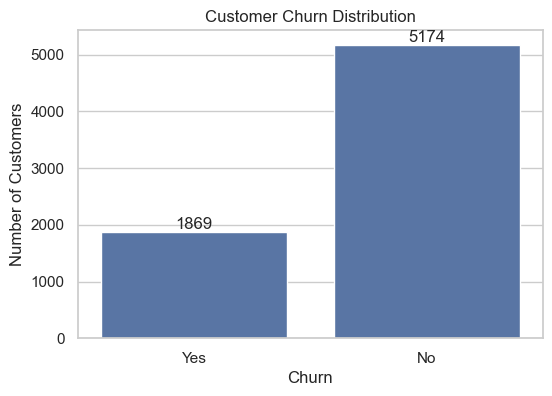

In [25]:
# A visualisation of the churn label count

plt.figure(figsize=(6, 4))
plot = sns.countplot(data = df, x = "Churn_Label")
plot.bar_label(plot.containers[0])
plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.show

### The company has an overall churn rate of approximately 26.5%, meaning around one in four customers left during the quarter. This indicates a significant retention problem and justifies deeper analysis into churn drivers.

In [26]:
# Saving the clean dataset

df.to_csv("/Users/alankar/Downloads/Customer Churn Project/project/data/processed/Telco_customer_churn.csv", index=False)
print("Cleaned dataset saved successfully.")

Cleaned dataset saved successfully.


In [27]:
cleaned_df = pd.read_csv("/Users/alankar/Downloads/Customer Churn Project/project/data/processed/Telco_customer_churn.csv")
cleaned_df

,CustomerID,Count,Country,State,City,Zip_Code,Lat_Long,Latitude,Longitude,Gender,Senior_Citizen,Partner,Dependents,Tenure_Months,Phone_Service,Multiple_Lines,Internet_Service,Online_Security,Online_Backup,Device_Protection,Tech_Support,Streaming_TV,Streaming_Movies,Contract,Paperless_Billing,Payment_Method,Monthly_Charges,Total_Charges,Churn_Label,Churn_Value,Churn_Score,CLTV,Churn_Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,No,No,Yes,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.50,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,No,No,Yes,49,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.30,Yes,1,89,5340,Competitor had better devices
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,2569-WGERO,1,United States,California,Landers,92285,"34.341737, -116.539416",34.341737,-116.539416,Female,No,No,No,72,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Bank transfer (automatic),21.15,1419.40,No,0,45,5306,NaN
7039,6840-RESVB,1,United States,California,Adelanto,92301,"34.667815, -117.536183",34.667815,-117.536183,Male,No,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No,0,59,2140,NaN
7040,2234-XADUH,1,United States,California,Amboy,92304,"34.559882, -115.637164",34.559882,-115.637164,Female,No,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No,0,71,5560,NaN
7041,4801-JZAZL,1,United States,California,Angelus Oaks,92305,"34.1678, -116.86433",34.167800,-116.864330,Female,No,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No,0,59,2793,NaN


In [28]:
df

,CustomerID,Count,Country,State,City,Zip_Code,Lat_Long,Latitude,Longitude,Gender,Senior_Citizen,Partner,Dependents,Tenure_Months,Phone_Service,Multiple_Lines,Internet_Service,Online_Security,Online_Backup,Device_Protection,Tech_Support,Streaming_TV,Streaming_Movies,Contract,Paperless_Billing,Payment_Method,Monthly_Charges,Total_Charges,Churn_Label,Churn_Value,Churn_Score,CLTV,Churn_Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,No,No,Yes,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.50,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,No,No,Yes,49,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.30,Yes,1,89,5340,Competitor had better devices
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,2569-WGERO,1,United States,California,Landers,92285,"34.341737, -116.539416",34.341737,-116.539416,Female,No,No,No,72,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Bank transfer (automatic),21.15,1419.40,No,0,45,5306,NaN
7039,6840-RESVB,1,United States,California,Adelanto,92301,"34.667815, -117.536183",34.667815,-117.536183,Male,No,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No,0,59,2140,NaN
7040,2234-XADUH,1,United States,California,Amboy,92304,"34.559882, -115.637164",34.559882,-115.637164,Female,No,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No,0,71,5560,NaN
7041,4801-JZAZL,1,United States,California,Angelus Oaks,92305,"34.1678, -116.86433",34.167800,-116.864330,Female,No,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No,0,59,2793,NaN


#

### SQL business analysis, where we’ll answer:

- Overall churn rate
- Churn by contract type
- Churn by payment method
- Churn by internet service
- Churn by tenure group
- Churn by senior citizen status
- Churn by support services
- Churn reasons
- Revenue at risk
- City-level churn hotspots

In [29]:
# =============================================
# SQL 
# =============================================

In [30]:
# Creating an in-memory SQLite database
conn = sqlite3.connect(":memory:")

# Load dataframe into SQL table
df.to_sql("telco_churn", conn, index=False, if_exists="replace")

print("Data loaded into SQLite successfully.")

Data loaded into SQLite successfully.


In [31]:
# Helper function to make sql queries easier

def run_query(query):
    return pd.read_sql_query(query, conn)

#

### Overall Churn Rate

In [32]:
query = """
SELECT
    COUNT(*) AS total_customers,
    SUM(Churn_Value) AS churned_customers,
    ROUND(AVG(Churn_Value) * 100, 2) AS churn_rate_percent
FROM telco_churn;
"""

run_query(query)

,total_customers,churned_customers,churn_rate_percent
0,7043,1869,26.54


### Insight: Overall Churn Rate

The SQL analysis shows that out of 7,043 customers, 1,869 customers churned during the observed period. This gives an overall churn rate of **26.54%**, meaning roughly one in four customers left the company.

From a business perspective, this is a significant retention issue. A churn rate above 25% suggests that the company should not only predict which customers are likely to leave, but also understand the key drivers behind churn and prioritise high-risk customer groups for retention campaigns.

#

### Churn by Contract Type

In [33]:
query = """
SELECT
    contract,
    COUNT(*) AS total_customers,
    SUM(Churn_Value) AS churned_customers,
    ROUND(AVG(Churn_Value) * 100, 2) AS churn_rate_percent,
    ROUND(SUM(Monthly_Charges), 2) AS total_monthly_revenue,
    ROUND(SUM(CASE WHEN Churn_Value = 1 THEN Monthly_Charges ELSE 0 END), 2) AS monthly_revenue_lost
FROM telco_churn
GROUP BY contract
ORDER BY churn_rate_percent DESC;
"""

contract_churn = run_query(query)
contract_churn

,Contract,total_customers,churned_customers,churn_rate_percent,total_monthly_revenue,monthly_revenue_lost
0,Month-to-month,3875,1655,42.71,257294.15,120847.10
1,One year,1473,166,11.27,95816.60,14118.45
2,Two year,1695,48,2.83,103005.85,4165.30


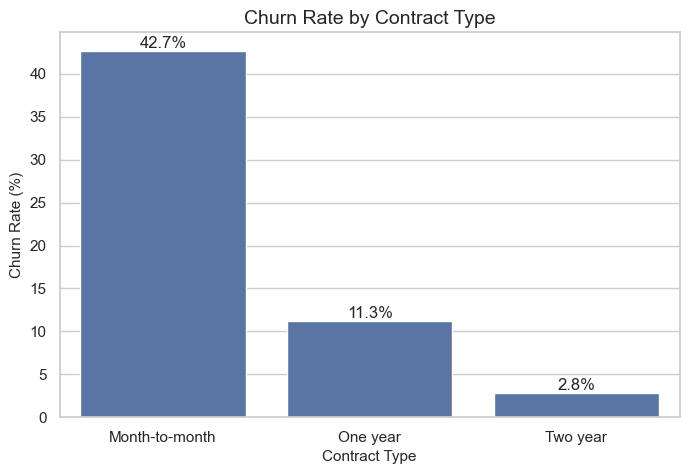

In [131]:
plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=contract_churn,
    x="Contract",
    y="churn_rate"
)

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

plt.show()

### Insight: Churn by Contract Type

Contract type shows one of the strongest relationships with churn. Customers on **month-to-month contracts** have the highest churn rate at **42.71%**, compared with **11.27%** for one-year contracts and only **2.83%** for two-year contracts.

This suggests that customers with lower contractual commitment are much more likely to leave. Month-to-month customers also account for the largest monthly revenue loss, with approximately **$120,847** in lost monthly revenue from churned customers.

From a business perspective, this segment should be treated as a high-priority retention group. The company could consider offering loyalty discounts, contract upgrade incentives, or bundled service benefits to encourage month-to-month customers to move towards longer-term plans.

#### Contract type appears to be one of the strongest churn indicators. Customers on month-to-month contracts show substantially higher churn compared with customers on one-year or two-year contracts. This suggests that longer-term contracts may improve customer retention, while month-to-month customers should be prioritised for retention campaigns.

#

### Churn by Payment Method

In [134]:
query = """
SELECT
    Payment_Method,
    COUNT(*) AS total_customers,
    SUM(Churn_Value) AS churned_customers,
    ROUND(AVG(Churn_Value) * 100, 2) AS churn_rate_percent,
    ROUND(SUM(CASE WHEN Churn_Value = 1 THEN Monthly_Charges ELSE 0 END), 2) AS monthly_revenue_lost
FROM telco_churn
GROUP BY Payment_Method
ORDER BY churn_rate_percent DESC;
"""

payment_churn = run_query(query)
payment_churn

,Payment_Method,total_customers,churned_customers,churn_rate_percent,monthly_revenue_lost
0,Electronic check,2365,1071,45.29,84288.75
1,Mailed check,1612,308,19.11,16803.60
2,Bank transfer (automatic),1544,258,16.71,20091.90
3,Credit card (automatic),1522,232,15.24,17946.60


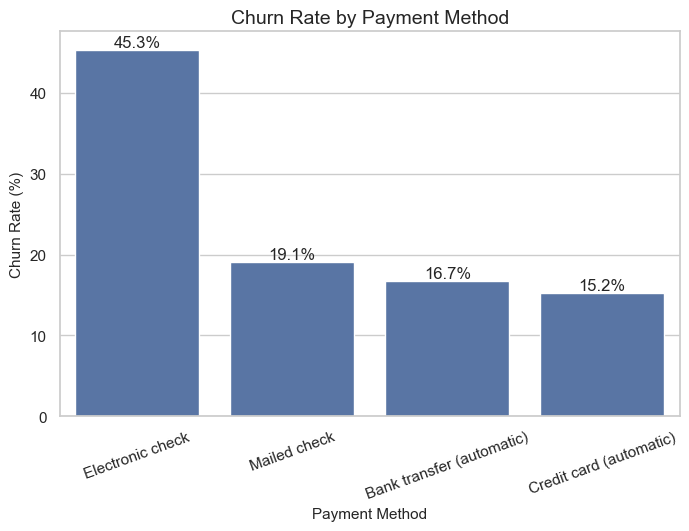

In [135]:
plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=payment_churn,
    x="Payment_Method",
    y="churn_rate_percent"
)

plt.title("Churn Rate by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=20)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

plt.show()

### Insight: Churn by Payment Method

Payment method also appears to be strongly associated with churn. Customers using **electronic check** have the highest churn rate at **45.29%**, which is substantially higher than mailed check customers at **19.11%**, bank transfer customers at **16.71%**, and credit card automatic payment customers at **15.24%**.

Electronic check customers also represent the highest monthly revenue loss, with approximately **$84,289** lost from churned customers in this group.

This may indicate that customers using electronic checks are less committed, experience more payment friction, or are less engaged with automatic payment methods. From a retention perspective, the company could encourage these customers to switch to automatic payment methods through incentives, simplified billing communication, or payment convenience benefits.

#

### Churn by Internet Service

In [136]:
query = """
SELECT
    internet_service,
    COUNT(*) AS total_customers,
    SUM(Churn_Value) AS churned_customers,
    ROUND(AVG(Churn_Value) * 100, 2) AS churn_rate_percent,
    ROUND(AVG(Monthly_Charges), 2) AS avg_monthly_charge,
    ROUND(SUM(CASE WHEN Churn_Value = 1 THEN Monthly_Charges ELSE 0 END), 2) AS monthly_revenue_lost
FROM telco_churn
GROUP BY internet_service
ORDER BY churn_rate_percent DESC;
"""

internet_churn = run_query(query)
internet_churn

,Internet_Service,total_customers,churned_customers,churn_rate_percent,avg_monthly_charge,monthly_revenue_lost
0,Fiber optic,3096,1297,41.89,91.50,114300.05
1,DSL,2421,459,18.96,58.10,22529.20
2,No,1526,113,7.40,21.08,2301.60


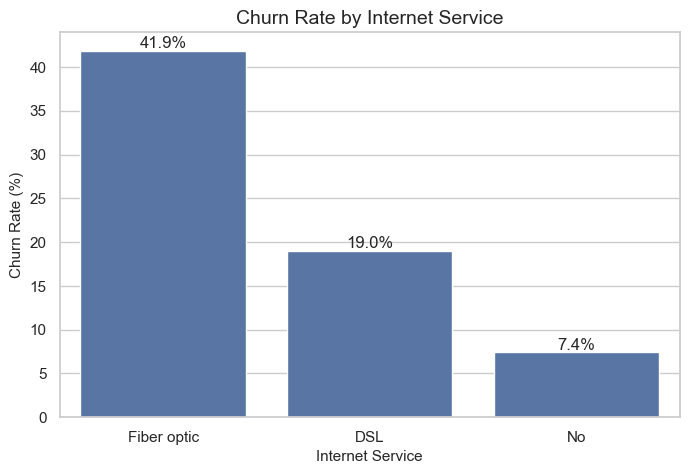

In [137]:
plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=internet_churn,
    x="Internet_Service",
    y="churn_rate_percent"
)

plt.title("Churn Rate by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Churn Rate (%)")

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

plt.show()

### Insight: Churn by Internet Service

Internet service type shows a clear churn pattern. Customers using **fiber optic** service have the highest churn rate at **41.89%**, compared with **18.96%** for DSL customers and **7.40%** for customers with no internet service.

Fiber optic customers also have the highest average monthly charge at **$91.50** and account for the largest monthly revenue loss, approximately **$114,300**. This makes fiber optic customers both high-risk and financially important.

From a business perspective, this could suggest issues around pricing, service reliability, customer expectations, or competitor pressure in the fiber optic segment. The company should investigate whether fiber optic customers are leaving due to service dissatisfaction, network performance, or better competitor offers.

#

### Churn by Tenure Group

In [114]:
# Creating tenure groups

df["Tenure_Group"] = pd.cut(
    df["Tenure_Months"],
    bins=[-1, 0, 12, 24, 48, 72],
    labels=["0 months", "1-12 months", "13-24 months", "25-48 months", "49-72 months"]
)

df.to_csv("/Users/alankar/Downloads/Customer Churn Project/project/data/processed/Telco_customer_churn.csv", index=False)

# Refresh SQL table after adding tenure_group
df.to_sql("telco_churn", conn, index=False, if_exists="replace")

7043

In [139]:
query = """
SELECT
    tenure_group,
    COUNT(*) AS total_customers,
    SUM(Churn_Value) AS churned_customers,
    ROUND(AVG(Churn_Value) * 100, 2) AS churn_rate_percent,
    ROUND(AVG(Monthly_Charges), 2) AS avg_monthly_charge,
    ROUND(SUM(CASE WHEN Churn_Value = 1 THEN Monthly_Charges ELSE 0 END), 2) AS monthly_revenue_lost
FROM telco_churn
GROUP BY tenure_group
ORDER BY 
    CASE tenure_group
        WHEN '0 months' THEN 1
        WHEN '1-12 months' THEN 2
        WHEN '13-24 months' THEN 3
        WHEN '25-48 months' THEN 4
        WHEN '49-72 months' THEN 5
    END;
"""

tenure_churn = run_query(query)
tenure_churn

,Tenure_Group,total_customers,churned_customers,churn_rate_percent,avg_monthly_charge,monthly_revenue_lost
0,0 months,11,0,0.00,41.42,0.00
1,1-12 months,2175,1037,47.68,56.17,68954.25
2,13-24 months,1024,294,28.71,61.36,23081.65
3,25-48 months,1594,325,20.39,65.93,27462.50
4,49-72 months,2239,213,9.51,73.95,19632.45


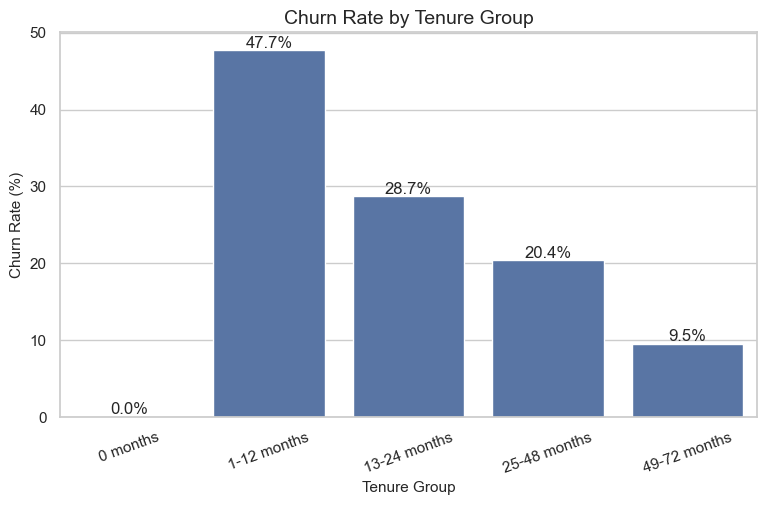

In [140]:
plt.figure(figsize=(9, 5))

ax = sns.barplot(
    data=tenure_churn,
    x="Tenure_Group",
    y="churn_rate_percent"
)

plt.title("Churn Rate by Tenure Group")
plt.xlabel("Tenure Group")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=20)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

plt.show()

### Insight: Churn by Tenure Group

Tenure shows a strong inverse relationship with churn. Customers in the **1–12 month** tenure group have the highest churn rate at **47.68%**, while customers with **49–72 months** of tenure have a much lower churn rate of **9.51%**.

This suggests that churn is heavily concentrated among early-stage customers. The first year appears to be the most critical retention window, with over 1,000 churned customers coming from the 1–12 month group alone.

Although customers with longer tenure have higher average monthly charges, their churn rates are much lower. From a business perspective, the company should focus on improving onboarding, early customer support, first-year engagement, and proactive check-ins for new customers.

#

### Churn by Senior Citizen Status

In [106]:
query = """
SELECT
    senior_citizen,
    COUNT(*) AS total_customers,
    SUM(Churn_Value) AS churned_customers,
    ROUND(AVG(Churn_Value) * 100, 2) AS churn_rate_percent,
    ROUND(SUM(CASE WHEN Churn_Value = 1 THEN Monthly_Charges ELSE 0 END), 2) AS monthly_revenue_lost
FROM telco_churn
GROUP BY senior_citizen
ORDER BY churn_rate_percent DESC;
"""

senior_churn = run_query(query)
senior_churn

,Senior_Citizen,total_customers,churned_customers,churn_rate_percent,monthly_revenue_lost
0,Yes,1142,476,41.68,38419.60
1,No,5901,1393,23.61,100711.25


### Insight: Churn by Senior Citizen Status

Senior citizens show a considerably higher churn rate than non-senior customers. The churn rate for senior citizens is **41.68%**, compared with **23.61%** for non-senior customers.

Although senior citizens make up a smaller customer group, their churn rate is almost double that of non-senior customers. This may indicate that senior customers face different challenges, such as price sensitivity, service complexity, support accessibility, or lower satisfaction with digital service channels.

From a business perspective, the company could investigate whether senior customers require simpler plan options, clearer billing communication, more accessible support, or targeted retention offers.

#

### Churn by Support Services

In [109]:
# This checks whether customers with add-on support services churn less.

query = """
SELECT
    tech_support,
    COUNT(*) AS total_customers,
    SUM(Churn_Value) AS churned_customers,
    ROUND(AVG(Churn_Value) * 100, 2) AS churn_rate_percent,
    ROUND(SUM(CASE WHEN Churn_Value = 1 THEN Monthly_Charges ELSE 0 END), 2) AS monthly_revenue_lost
FROM telco_churn
GROUP BY tech_support
ORDER BY churn_rate_percent DESC;
"""

tech_support_churn = run_query(query)
tech_support_churn

,Tech_Support,total_customers,churned_customers,churn_rate_percent,monthly_revenue_lost
0,No,3473,1446,41.64,110709.80
1,Yes,2044,310,15.17,26119.45
2,No internet service,1526,113,7.40,2301.60


### Insight: Churn by Tech Support

Customers without tech support have a much higher churn rate at **41.64%**, compared with **15.17%** for customers who have tech support. Customers with no internet service show a much lower churn rate of **7.40%**, but this group is not directly comparable because tech support is not applicable to them.

This suggests that technical support may be linked to stronger retention among internet customers. Customers without tech support may experience unresolved service issues, lower perceived value, or higher frustration when problems occur.

From a business perspective, offering discounted or bundled tech support to high-risk customers could be a practical retention strategy, especially for customers using internet services.

In [110]:
query = """
SELECT
    online_security,
    COUNT(*) AS total_customers,
    SUM(churn_value) AS churned_customers,
    ROUND(AVG(churn_value) * 100, 2) AS churn_rate_percent,
    ROUND(SUM(CASE WHEN churn_value = 1 THEN monthly_charges ELSE 0 END), 2) AS monthly_revenue_lost
FROM telco_churn
GROUP BY online_security
ORDER BY churn_rate_percent DESC;
"""

online_security_churn = run_query(query)
online_security_churn

,Online_Security,total_customers,churned_customers,churn_rate_percent,monthly_revenue_lost
0,No,3498,1461,41.77,112762.75
1,Yes,2019,295,14.61,24066.50
2,No internet service,1526,113,7.40,2301.60


In [ ]:
plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=tech_support_churn,
    x="Tech_Support",
    y="churn_rate"
)

plt.title("Churn Rate by Tech Support Subscription")
plt.xlabel("Tech Support")
plt.ylabel("Churn Rate (%)")

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

plt.show()

### Insight: Churn by Online Security

A similar pattern appears for online security. Customers without online security have a churn rate of **41.77%**, compared with **14.61%** for customers who subscribe to online security. Customers with no internet service again show a much lower churn rate of **7.40%**, but this category means the service is not applicable.

This suggests that customers with additional protective services may be more engaged or may perceive greater value from the company’s service bundle. Customers without online security could represent a weaker relationship with the provider.

From a business perspective, online security could be explored as part of a retention bundle for high-risk internet customers, especially those on month-to-month contracts or fiber optic plans.

### Treatment of `No internet service` Categories

Several internet-related service columns contain three categories: `Yes`, `No`, and `No internet service`. This occurs in columns such as `online_security`, `online_backup`, `device_protection`, `tech_support`, `streaming_tv`, and `streaming_movies`.

The value `No internet service` is not a missing value or data error. It indicates that the customer does not subscribe to internet service, so the related add-on service is not applicable.

This category was kept separate during SQL analysis and EDA because it has a different meaning from `No`. A value of `No` means the customer has internet service but has not subscribed to that specific add-on. In contrast, `No internet service` means the customer is not eligible for the add-on because they do not have internet service.

Combining `No internet service` with `No` would incorrectly mix two different customer groups and could distort churn insights. Therefore, all three categories were retained for analysis.

#

### Churn Reasons

In [143]:
query = """
SELECT
    churn_reason,
    COUNT(*) AS churned_customers,
    ROUND(COUNT(*) * 100.0 / (SELECT COUNT(*) FROM telco_churn WHERE churn_value = 1), 2) AS percent_of_churned_customers
FROM telco_churn
WHERE churn_value = 1
GROUP BY churn_reason
ORDER BY churned_customers DESC;
"""

churn_reasons = run_query(query)
churn_reasons

,Churn_Reason,churned_customers,percent_of_churned_customers
0,Attitude of support person,192,10.27
1,Competitor offered higher download speeds,189,10.11
2,Competitor offered more data,162,8.67
3,Don't know,154,8.24
4,Competitor made better offer,140,7.49
5,Attitude of service provider,135,7.22
6,Competitor had better devices,130,6.96
7,Network reliability,103,5.51
8,Product dissatisfaction,102,5.46
9,Price too high,98,5.24


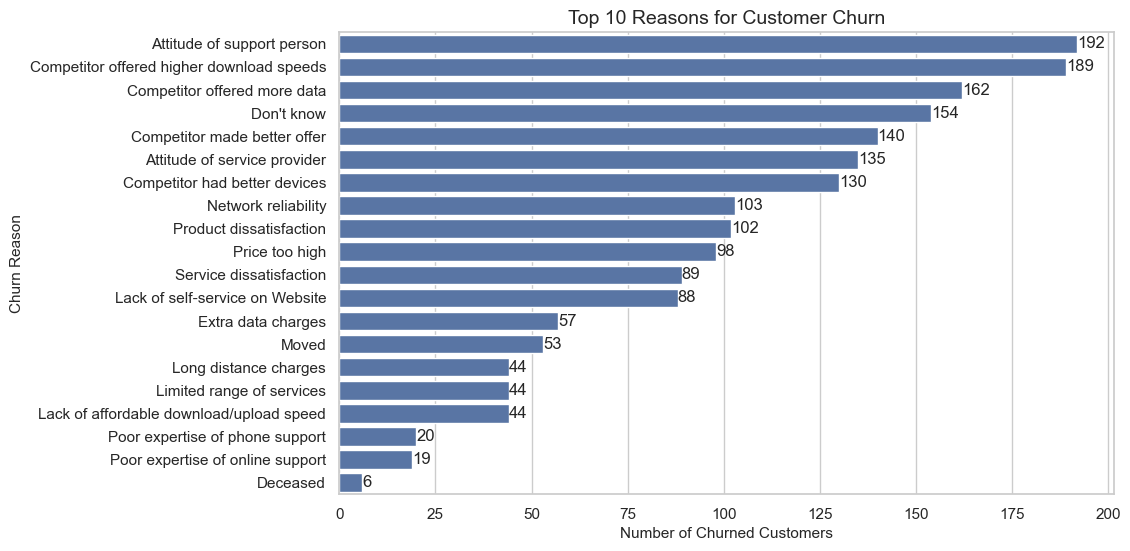

In [144]:
plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=churn_reasons,
    x="churned_customers",
    y="Churn_Reason"
)

plt.title("Top 10 Reasons for Customer Churn")
plt.xlabel("Number of Churned Customers")
plt.ylabel("Churn Reason")

for container in ax.containers:
    ax.bar_label(container)

plt.show()

### Insight: Churn Reasons

The churn reason analysis provides an explanation of why customers left. The most common churn reason is **attitude of support person**, accounting for **10.27%** of churned customers. This is followed closely by competitor-related reasons such as **competitor offered higher download speeds** at **10.11%**, **competitor offered more data** at **8.67%**, and **competitor made better offer** at **7.49%**.

Several of the top churn reasons relate to either customer service experience or competitor offerings. This suggests that churn is not driven by a single issue, but by a combination of service quality, support experience, pricing, and competitive pressure.

From a business perspective, the company should prioritise two areas: improving support interactions and strengthening competitor-response strategies. This could include support staff training, faster complaint resolution, better data/speed packages, and targeted offers for customers at risk of switching providers.

#

### Revenue at Risk

In [112]:
query = """
SELECT
    ROUND(SUM(CASE WHEN Churn_Value = 1 THEN Monthly_Charges ELSE 0 END), 2) AS monthly_revenue_lost,
    ROUND(SUM(CASE WHEN Churn_Value = 1 THEN Monthly_Charges ELSE 0 END) * 12, 2) AS annualised_revenue_lost
FROM telco_churn;
"""

run_query(query)

,monthly_revenue_lost,annualised_revenue_lost
0,139130.85,1669570.2


### Insight: Revenue at Risk

The total monthly revenue lost from churned customers is approximately **$139,131**. Annualised, this represents around **$1.67 million** in revenue at risk.

This is a key business finding because it translates churn from a customer-count problem into a financial problem. Instead of only asking how many customers are leaving, the company can estimate how much recurring revenue is being lost.

This supports the need for a retention strategy that prioritises customers not only by churn risk, but also by financial value.

#

### City-Level Churn Hotspots

In [113]:
query = """
SELECT
    city,
    COUNT(*) AS total_customers,
    SUM(Churn_Value) AS churned_customers,
    ROUND(AVG(Churn_Value) * 100, 2) AS churn_rate_percent,
    ROUND(SUM(CASE WHEN Churn_Value = 1 THEN Monthly_Charges ELSE 0 END), 2) AS monthly_revenue_lost
FROM telco_churn
GROUP BY city
HAVING COUNT(*) >= 20
ORDER BY churn_rate_percent DESC
LIMIT 15;
"""

city_churn = run_query(query)
city_churn

,City,total_customers,churned_customers,churn_rate_percent,monthly_revenue_lost
0,Santa Rosa,24,11,45.83,726.35
1,North Hollywood,20,9,45.00,594.00
2,Modesto,28,12,42.86,870.20
3,Santa Barbara,28,10,35.71,860.70
4,San Diego,150,50,33.33,3528.90
5,Glendale,40,13,32.50,633.55
6,Torrance,25,8,32.00,654.10
7,Pasadena,30,9,30.00,703.10
8,San Francisco,104,31,29.81,2476.60
9,Los Angeles,305,90,29.51,6620.70


### Insight: City-Level Churn Hotspots

The city-level analysis highlights geographic areas with unusually high churn rates. Among cities with at least 20 customers, **Santa Rosa** has the highest churn rate at **45.83%**, followed by **North Hollywood** at **45.00%** and **Modesto** at **42.86%**.

Larger cities such as **Los Angeles**, **San Diego**, **San Francisco**, and **San Jose** also contribute meaningful revenue loss because they have larger customer bases. For example, Los Angeles has 305 customers, 90 churned customers, and approximately **$6,621** in lost monthly revenue.

From a business perspective, smaller cities with very high churn rates may require localised investigation, while larger cities with high total revenue loss may be more important for large-scale retention campaigns. This shows why both churn rate and revenue loss should be considered together.

#

### Summary of SQL Business Findings

The SQL analysis revealed several important churn patterns:

- The overall churn rate is **26.54%**, indicating a significant retention issue.
- **Month-to-month customers** are the highest-risk contract group, with a churn rate of **42.71%**.
- **Electronic check** customers have the highest churn rate by payment method at **45.29%**.
- **Fiber optic** customers show the highest churn rate by internet service at **41.89%** and account for the largest monthly revenue loss.
- Customers in their first year have the highest churn rate at **47.68%**, making early-tenure retention a priority.
- Senior citizens churn at a higher rate than non-senior customers.
- Customers without tech support or online security show much higher churn than those with these services.
- The company is losing approximately **$139,131 in monthly recurring revenue**, equivalent to around **$1.67 million annually**.
- Churn reasons suggest that customer service experience and competitor offers are major drivers of customer loss.

Overall, the SQL analysis suggests that the highest-priority retention segment is likely to include customers who are early-tenure, month-to-month, fiber optic users, paying by electronic check, and lacking support-related add-on services.

#

#

### EDA Visualisations + Business Insights

#### We’ll cover:

- Overall churn distribution
- Churn by contract type
- Churn by payment method
- Churn by internet service
- Churn by tenure group
- Monthly charges vs churn
- Churn by support services
- Churn reasons
- Revenue lost by key segments

In [116]:
# =============================================
# EDA Visualisations
# =============================================

In [117]:
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 11

### Why SQL Outputs Are Used for Visualisation

The initial business analysis was performed using SQL to simulate how customer churn analysis would typically be conducted in a real business environment, where customer data is often stored in relational databases.

The SQL queries were used to create aggregated business tables such as churn rate by contract type, payment method, internet service, tenure group, and revenue at risk.

For the visualisation stage, these SQL query outputs were reused as pandas DataFrames and plotted using Python. This avoids duplicating the same aggregation logic in pandas and creates a clear workflow:

`SQL query → aggregated business table → Python visualisation → business insight`

### Churn Rate by Tech Support

In [141]:
tech_support_churn = (
    df.groupby("Tech_Support")
    .agg(
        total_customers=("CustomerID", "count"),
        churn_rate=("Churn_Value", "mean")
    )
    .reset_index()
)

tech_support_churn["churn_rate"] = tech_support_churn["churn_rate"] * 100
tech_support_churn = tech_support_churn.sort_values("churn_rate", ascending=False)

tech_support_churn

,Tech_Support,total_customers,churn_rate
0,No,3473,41.635474
2,Yes,2044,15.166341
1,No internet service,1526,7.404980


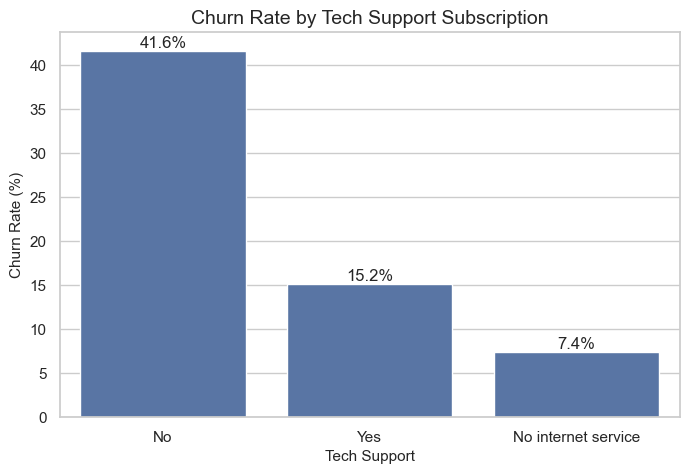

In [142]:
plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=tech_support_churn,
    x="Tech_Support",
    y="churn_rate"
)

plt.title("Churn Rate by Tech Support Subscription")
plt.xlabel("Tech Support")
plt.ylabel("Churn Rate (%)")

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

plt.show()

### Insight: Churn Rate by Tech Support 

The visualisation shows a clear difference in churn based on whether customers subscribe to tech support. Customers without tech support have the highest churn rate at **41.6%**, while customers with tech support have a much lower churn rate of **15.2%**.

This suggests that tech support may play an important role in customer retention. Customers who do not have access to technical support may be more likely to experience unresolved service issues, frustration, or lower perceived value from the company’s services.

The `No internet service` category has the lowest churn rate at **7.4%**, but this group should be interpreted separately because tech support is not applicable to customers who do not subscribe to internet service.

From a business perspective, customers without tech support represent a high-risk segment. The company could consider offering discounted tech support, bundled support packages, or proactive service check-ins to customers who are likely to churn, especially those using internet services.

#

### Monthly Revenue Lost by Contract Type

In [146]:
contract_revenue_lost = (
    df[df["Churn_Value"] == 1]
    .groupby("Contract")
    .agg(monthly_revenue_lost=("Monthly_Charges", "sum"))
    .reset_index()
    .sort_values("monthly_revenue_lost", ascending=False)
)

contract_revenue_lost

,Contract,monthly_revenue_lost
0,Month-to-month,120847.10
1,One year,14118.45
2,Two year,4165.30


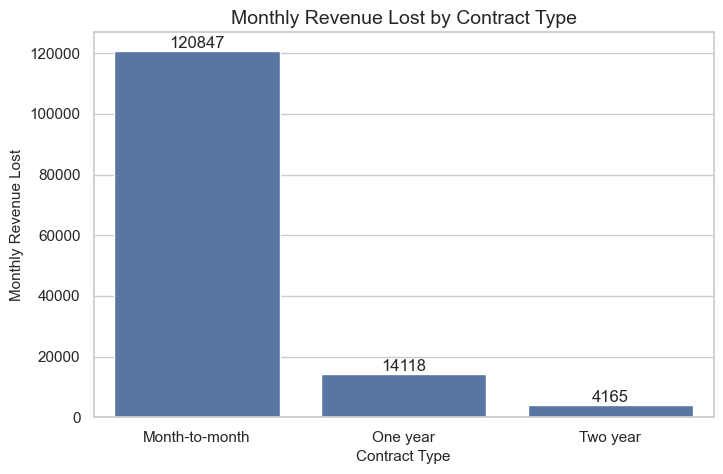

In [147]:
plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=contract_revenue_lost,
    x="Contract",
    y="monthly_revenue_lost"
)

plt.title("Monthly Revenue Lost by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Monthly Revenue Lost")

for container in ax.containers:
    ax.bar_label(container, fmt="%.0f")

plt.show()

### Insight: Monthly Revenue Lost by Contract Type

The visualisation shows that monthly revenue loss is heavily concentrated among customers on **month-to-month contracts**. Churned month-to-month customers account for approximately **USD 120,847** in lost monthly revenue, compared with only **USD 14,118** from one-year contracts and **USD 4,165** from two-year contracts.

This confirms that month-to-month customers are not only more likely to churn, but also responsible for the largest financial impact. The gap is substantial, showing that the company’s churn problem is strongly linked to customers with low contractual commitment.

From a business perspective, this segment should be a top priority for retention campaigns. The company could target month-to-month customers with loyalty incentives, contract upgrade offers, discounted bundles, or personalised retention offers before they leave.

This chart also highlights why churn should be analysed using both customer count and financial impact. A segment with high churn becomes even more important when it also contributes heavily to recurring revenue loss.

#

In [148]:
# Saving key EDA tables

contract_churn.to_csv("../data/processed/contract_churn_summary.csv", index=False)
payment_churn.to_csv("../data/processed/payment_churn_summary.csv", index=False)
internet_churn.to_csv("../data/processed/internet_churn_summary.csv", index=False)
tenure_churn.to_csv("../data/processed/tenure_churn_summary.csv", index=False)
churn_reasons.to_csv("../data/processed/top_churn_reasons.csv", index=False)

print("EDA summary tables saved successfully.")

EDA summary tables saved successfully.


#

## Notebook 1 Summary

This notebook focused on understanding the telecom churn dataset through data cleaning, SQL-based business analysis, and exploratory visualisation.

The dataset contains 7,043 customers, with an overall churn rate of 26.54%. SQL analysis showed that churn is especially high among month-to-month customers, electronic check users, fiber optic customers, early-tenure customers, senior citizens, and customers without support-related services such as tech support or online security.

The financial analysis showed that churned customers account for approximately USD 139,131 in lost monthly recurring revenue, equivalent to around USD 1.67 million on an annualised basis. Month-to-month contracts and fiber optic customers represent the largest revenue-risk areas.

The analysis also showed that customer support experience and competitor offers are major churn reasons. These findings suggest that churn is driven by a combination of contract flexibility, service experience, payment behaviour, pricing pressure, and competitive alternatives.

The next notebook will use these insights to build a machine learning model that predicts churn risk and creates a retention priority framework based on predicted churn probability and customer value.